# Deep Analysis — Aspect-Based Sentiment Analysis (ABSA)
**Goal:** Identify which product aspects (packaging, scent, skin reaction, etc.) carry hidden dissatisfaction — especially inside high-rated (4★+) reviews.

**Approach:** TF-IDF finds complaint words → aspect dictionary built from findings → VADER scores every review → aspect + sentiment combined → hidden dissatisfaction in 4★+ isolated → segmented by skin type and price tier.

**Flow:**
```
Load data → VADER sentiment → TF-IDF discovery → Aspect extraction → Explode
→ Aspect sentiment table → Hidden dissatisfaction → Skin type → Price tier → Summary
```



## Section 1 — Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Load
df = pd.read_csv('../sephora/clean_reviews.csv', parse_dates=['review_date'])
print(f"Full dataset: {df.shape}")

# Create price_tier from price_usd before sampling so it's available downstream
df['price_tier'] = pd.cut(
    df['price_usd'],
    bins=[0, 25, 50, 100, 9999],
    labels=['budget(<$25)', 'mid($25-50)', 'premium($50-100)', 'luxury($100+)']
)
print(f"price_tier distribution:\n{df['price_tier'].value_counts().sort_index()}")

# Working sample
df_sample = df.sample(n=300000, random_state=42).copy()
print(f"Sample: {df_sample.shape}")
df_sample.head(2)

Full dataset: (1033710, 10)
price_tier distribution:
price_tier
budget(<$25)        267502
mid($25-50)         414054
premium($50-100)    297886
luxury($100+)        54268
Name: count, dtype: int64
Sample: (300000, 11)


,product_id,product_name,brand_name,price_usd,rating,review_text,skin_type,review_date,word_count,clean_text,price_tier
104802,P471546,Mini Cicapair Tiger Grass Color Correcting Tre...,Dr. Jart+,21.0,2,I’m sad because I wanted to love this product ...,NaN,2023-01-15,150,im sad because i wanted to love this product b...,budget(<$25)
233454,P232915,ExfoliKate Intensive Pore Exfoliating Treatment,Kate Somerville,98.0,5,"This stuff is great. Yes, it is expensive...bu...",NaN,2016-02-17,103,this stuff is great yes it is expensivebut you...,premium($50-100)


## Section 2 — VADER Sentiment Scoring
Score every review first. This is independent of aspects and must come before aspect analysis.

In [2]:
analyzer = SentimentIntensityAnalyzer()

df_sample['vader_score'] = df_sample['review_text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

df_sample['sentiment_label'] = df_sample['vader_score'].apply(
    lambda x: 'positive' if x >= 0.05
              else ('negative' if x <= -0.05 else 'neutral')
)

# Distribution check
dist = df_sample['sentiment_label'].value_counts(normalize=True) * 100
print("Sentiment distribution (%):\n", dist.round(2))

Sentiment distribution (%):
 sentiment_label
positive    89.19
negative     7.99
neutral      2.82
Name: proportion, dtype: float64


In [3]:
# Sanity check: do VADER labels align with star ratings?
# Expectation: 1★ reviews → mostly negative, 5★ → mostly positive
pd.crosstab(
    df_sample['rating'],
    df_sample['sentiment_label'],
    normalize='index'
).round(2)

sentiment_label,negative,neutral,positive
rating,,,
1,0.44,0.08,0.48
2,0.26,0.06,0.67
3,0.14,0.04,0.82
4,0.05,0.02,0.93
5,0.03,0.02,0.95


**VADER Sentiment Distribution:**
89.2% of reviews score positive, 8.0% negative, and 2.8% neutral —
consistent with the positive rating skew identified in EDA. Importantly,
even 5★ reviews contain 3% negative sentiment, confirming that customers
write complaints inside high-rated reviews. This is the foundation of the
hidden dissatisfaction hypothesis.

**Sanity check passed:** Negative sentiment decreases monotonically from
44% at 1★ to 3% at 5★, confirming VADER is capturing sentiment direction
correctly across this dataset.

## Section 3 — TF-IDF Complaint Word Discovery
Find which words statistically dominate 1★ vs 5★ reviews. This drives the aspect dictionary.

In [4]:
df_1star = df[df['rating'] == 1]['clean_text'].dropna()
df_5star = df[df['rating'] == 5]['clean_text'].dropna()

custom_stops = ['ive','im','dont','cant','didnt','doesnt',
                'wasnt','wouldnt','isnt','thats','its',
                'really','just','little','use','using',
                'used','product','got','try','tried',  
                'did','like','felt','feel','better','good','sure',
                'think','time','pretty','new','days','weeks', 
               'work','bought','buy','left','started','actually',
                'does','away','months','difference']

all_stops = list(ENGLISH_STOP_WORDS) + custom_stops

tfidf = TfidfVectorizer(stop_words=all_stops, max_features=100)
tfidf.fit(df['clean_text'].dropna())

X_1 = tfidf.transform(df_1star)
X_5 = tfidf.transform(df_5star)

words = tfidf.get_feature_names_out()
scores_1 = np.asarray(X_1.mean(axis=0)).flatten()
scores_5 = np.asarray(X_5.mean(axis=0)).flatten()

complaint_words = pd.DataFrame({
    'word': words,
    'score_1star': scores_1,
    'score_5star': scores_5,
    'difference': scores_1 - scores_5
}).sort_values('difference', ascending=False)

print("Top 30 complaint-driving words:")
print(complaint_words.head(30).to_string(index=False))

Top 30 complaint-driving words:
      word  score_1star  score_5star  difference
      face     0.098818     0.065692    0.033127
     break     0.038618     0.012536    0.026082
     smell     0.041784     0.024349    0.017435
 sensitive     0.042330     0.030617    0.011713
      acne     0.044801     0.035344    0.009456
    sticky     0.020048     0.010827    0.009221
    sample     0.029247     0.020603    0.008644
      eyes     0.029268     0.020713    0.008554
  products     0.040294     0.032430    0.007864
     price     0.024841     0.017218    0.007623
    bottle     0.023288     0.016072    0.007216
 breakouts     0.020295     0.014204    0.006091
       dry     0.053198     0.048688    0.004510
     worth     0.024268     0.020283    0.003986
      wash     0.017120     0.013149    0.003971
    smells     0.027906     0.024092    0.003814
       oil     0.027643     0.024488    0.003155
      oily     0.032517     0.029758    0.002759
 packaging     0.013459     0.010952 

**TF-IDF Complaint Word Analysis:**

The top complaint-driving words by TF-IDF difference score are:
`break` (+0.026), `smell` (+0.017), `sensitive` (+0.012), `acne` (+0.009),
`sticky` (+0.009), `bottle` (+0.007), and `price` (+0.008).

These words cluster into four natural complaint categories:
- **Packaging failure:** break, bottle
- **Skin reactions:** acne, sensitive, breakouts
- **Fragrance:** smell, smells
- **Texture problems:** sticky, greasy, oily

Words with negative difference scores (e.g., `absolutely`, `results`,
`sunscreen`) appear more in 5★ reviews — confirming they represent
satisfaction language, not complaints. The aspect dictionary in Section 4
is built directly from these statistical findings.

## Section 4 — Aspect Dictionary & Extraction
Built from TF-IDF findings above.

**Packaging** uses the tighter keyword set from deep_analysis — `break/broke` included because it had the 2nd highest TF-IDF score (+0.026) and specifically signals product failure. Neutral container words (`container`, `dispenser`) excluded to keep the complaint signal clean.

In [5]:
aspect_keywords = {
    # Tight packaging keywords ) — avoids dilution with neutral words
    'packaging':     ['pump', 'bottle', 'packaging', 'break', 'broke',
                      'leaked', 'cap', 'tube'],

    # Rich skin_reaction keywords 
    'skin_reaction': ['breakout', 'acne', 'irritation', 'rash', 'sensitive',
                      'reaction', 'redness', 'burning', 'purging', 'clog'],

    # Scent keywords
    'scent':         ['smell', 'scent', 'fragrance', 'odor',
                      'perfume', 'fragrant', 'stinks'],

    # Rich texture keywords 
    'texture':       ['texture', 'consistency', 'thick', 'thin', 'creamy',
                      'lightweight', 'heavy', 'greasy', 'sticky', 'watery'],

    # Rich hydration keywords 
    'hydration':     ['hydrating', 'moisturizing', 'dry', 'moisture',
                      'hydration', 'dewy', 'plump', 'tight'],

    # Price keywords
    'price':         ['expensive', 'cheap', 'worth', 'overpriced',
                      'value', 'affordable', 'price', 'cost']
}

def extract_aspects(text):
    found = []
    text  = str(text).lower()
    for aspect, keywords in aspect_keywords.items():
        if any(word in text for word in keywords):
            found.append(aspect)
    return found if found else ['none']

df_sample['aspects'] = df_sample['clean_text'].apply(extract_aspects)

aspect_counts = df_sample['aspects'].explode().value_counts()
print("Aspect mention counts:")
print(aspect_counts)
print(f"\nReviews with at least one aspect: {(df_sample['aspects'].apply(lambda x: x != ['none']).sum()):,}")
print(f"Reviews with no aspect match:     {(df_sample['aspects'].apply(lambda x: x == ['none']).sum()):,}")

Aspect mention counts:
aspects
texture          125969
hydration        101187
skin_reaction     74723
scent             74495
packaging         61315
none              57468
price             46752
Name: count, dtype: int64

Reviews with at least one aspect: 242,532
Reviews with no aspect match:     57,468


**Aspect Coverage:**

242,532 of 300,000 reviews (80.8%) mention at least one tracked aspect.
Texture is the most discussed aspect with 125,969 mentions — nearly double
the next closest category. Price is the least discussed at 46,752,
suggesting customers prioritize product performance over cost when writing
reviews.

19.2% of reviews mention no tracked aspect. These likely discuss topics
such as application technique, color, or SPF — areas outside the current
6-aspect framework. This is a documented limitation and acceptable for
Phase 1 analysis.

## Section 5 — Explode & Combine Aspect + Sentiment
Each review may mention multiple aspects. Exploding gives one row per aspect per review — correct method for multi-label analysis.

In [6]:
df_exploded = df_sample.explode('aspects').copy()

# Remove 'none' rows for cleaner analysis
df_exploded = df_exploded[df_exploded['aspects'] != 'none']

print(f"Rows after explode (excluding none): {df_exploded.shape[0]}")
df_exploded[['review_text', 'rating', 'aspects', 'sentiment_label']].head(5)

Rows after explode (excluding none): 484441


,review_text,rating,aspects,sentiment_label
104802,I’m sad because I wanted to love this product ...,2,skin_reaction,positive
104802,I’m sad because I wanted to love this product ...,2,texture,positive
104802,I’m sad because I wanted to love this product ...,2,price,positive
233454,"This stuff is great. Yes, it is expensive...bu...",5,skin_reaction,positive
233454,"This stuff is great. Yes, it is expensive...bu...",5,price,positive


## Section 6 — Core Result: Aspect Sentiment Table
This is the main deliverable. Shows complaint rate per aspect.

In [7]:
aspect_sentiment = pd.crosstab(
    df_exploded['aspects'],
    df_exploded['sentiment_label'],
    normalize='index'
) * 100

aspect_sentiment = aspect_sentiment.round(1)

# Sort by negative % descending — highest complaint aspects first
if 'negative' in aspect_sentiment.columns:
    aspect_sentiment = aspect_sentiment.sort_values('negative', ascending=False)

print("Aspect Sentiment Breakdown (%):")
print(aspect_sentiment)

Aspect Sentiment Breakdown (%):
sentiment_label  negative  neutral  positive
aspects                                     
packaging            11.5      2.0      86.5
skin_reaction        10.1      1.9      88.0
price                 7.8      1.5      90.7
texture               7.8      1.9      90.3
hydration             6.2      2.1      91.7
scent                 5.7      0.8      93.5


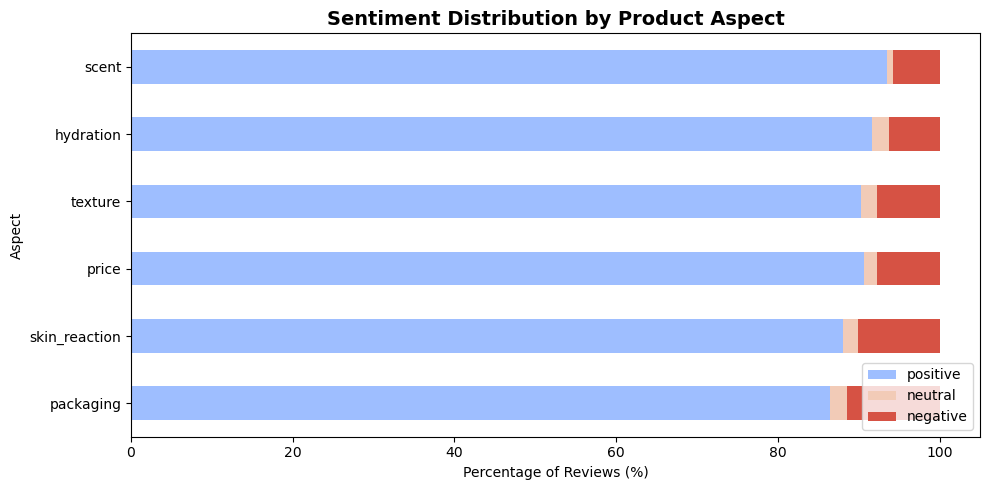

In [8]:
# Visualization: Stacked bar chart

cmap = plt.get_cmap('coolwarm') 
colors = [cmap(i) for i in np.linspace(0.3, 0.9, 3)]

ax = aspect_sentiment[['positive', 'neutral', 'negative']].plot(
    kind='barh',
    stacked=True,
    figsize=(10, 5),
    color=colors)

plt.title('Sentiment Distribution by Product Aspect', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Reviews (%)')
plt.ylabel('Aspect')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('aspect_sentiment_chart.png', dpi=150)
plt.show()

**Aspect Sentiment Results:**

Packaging shows the highest overall complaint rate at 11.5% — nearly 1 in 9
packaging mentions is negative. This points directly to physical product
quality issues such as pump failures and broken containers.

Skin reaction follows at 10.1%. These are health-adjacent complaints
(breakouts, irritation, redness) that carry higher customer impact than
cosmetic issues and are more likely to drive product returns.

Scent is the strongest performing aspect at only 5.7% negative, indicating
that fragrance profiles are broadly well-received. Hydration at 6.2%
negative also performs well — moisturizing claims are largely being
delivered.

Price and texture both sit at 7.8% negative, occupying the middle ground
between the high-complaint and low-complaint aspects.

## Section 7 — Hidden Dissatisfaction in 4★+ Reviews
**Core hypothesis:** High star ratings hide real complaints in specific aspects.
Filtering to 4★+ only and re-measuring the same sentiment breakdown.

In [9]:
df_4plus = df_exploded[df_exploded['rating'] >= 4].copy()

# Aspect sentiment breakdown within 4★+ only
hidden_sentiment = pd.crosstab(
    df_4plus['aspects'],
    df_4plus['sentiment_label'],
    normalize='index'
) * 100

hidden_sentiment = hidden_sentiment.round(1)

if 'negative' in hidden_sentiment.columns:
    hidden_sentiment = hidden_sentiment.sort_values('negative', ascending=False)

print("Hidden Dissatisfaction in 4★+ Reviews — Aspect Sentiment (%):")
print(hidden_sentiment)

Hidden Dissatisfaction in 4★+ Reviews — Aspect Sentiment (%):
sentiment_label  negative  neutral  positive
aspects                                     
skin_reaction         5.4      1.4      93.2
packaging             4.8      1.2      94.0
price                 3.5      0.8      95.7
texture               3.5      1.2      95.3
hydration             3.4      1.6      95.0
scent                 2.3      0.5      97.2



Negative review count per aspect in 4★+ reviews:
aspects
texture          3488
skin_reaction    3292
hydration        2881
packaging        2201
scent            1394
price            1249
dtype: int64


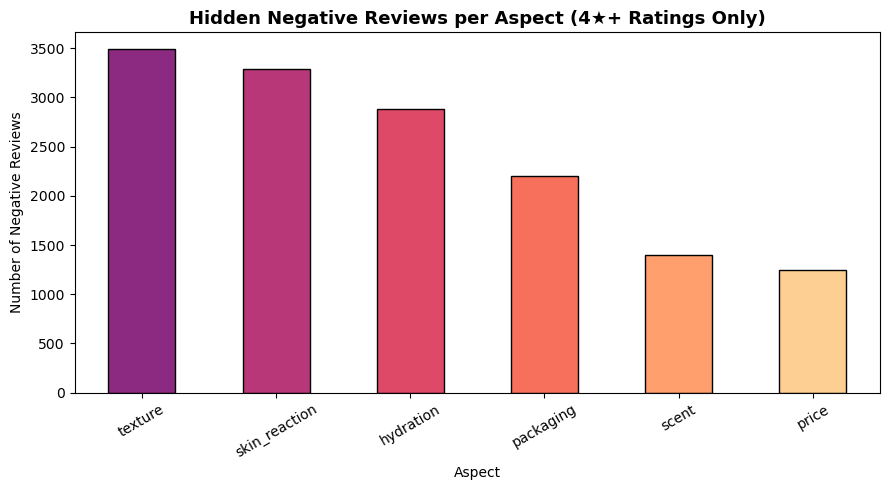

In [10]:
hidden_neg_counts = (
    df_4plus[df_4plus['sentiment_label'] == 'negative']
    .groupby('aspects')
    .size()
    .sort_values(ascending=False)
)

print("\nNegative review count per aspect in 4★+ reviews:")
print(hidden_neg_counts)

cmap = plt.get_cmap('magma')
colors = cmap(np.linspace(0.4, 0.9, len(hidden_neg_counts)))

# Visualization
hidden_neg_counts.plot(
    kind='bar',
    figsize=(9, 5),
    color=colors,
    edgecolor='black'
)
plt.title('Hidden Negative Reviews per Aspect (4★+ Ratings Only)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Aspect')
plt.ylabel('Number of Negative Reviews')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('hidden_dissatisfaction_chart.png', dpi=150)
plt.show()

**Hidden Dissatisfaction Analysis:**

Within 4★+ reviews, skin_reaction (5.4%) and packaging (4.8%) maintain
the highest hidden complaint rates — confirming these aspects generate
dissatisfaction even among customers who gave high ratings.

Texture reveals an important distinction between rate and volume. Despite
a moderate 3.5% hidden complaint rate, texture generates 3,488 hidden
negative reviews — the highest raw count of any aspect. This is driven by
its position as the most discussed aspect overall (125,969 mentions). A
small complaint rate multiplied by massive mention volume creates
significant complaint volume.

**Key business implication:** Skin reaction and packaging require
attention due to high complaint RATE. Texture requires attention due to
high complaint VOLUME. These are different types of problems requiring
different solutions.

## Section 8 — Segment by Skin Type

Negative reviews by skin type and aspect:
aspects      hydration  packaging  price  scent  skin_reaction  texture
skin_type                                                              
combination       2952       3510   1701   2036           3683     4721
dry               1496       1094    648    782           1249     1677
normal             568        712    458    502            646     1109
oily               556        926    443    469            988     1161


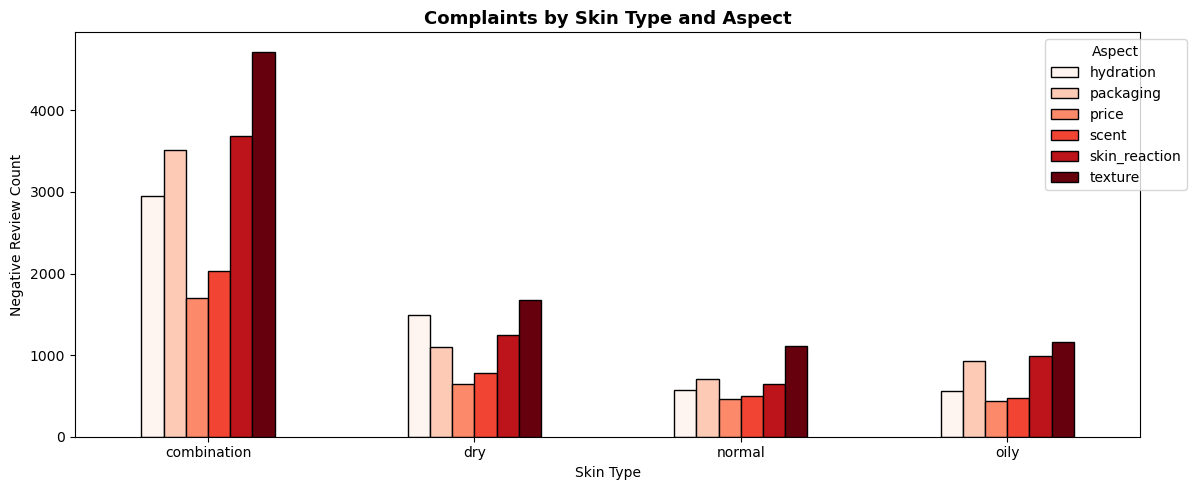

In [11]:
if 'skin_type' in df_exploded.columns:
    skin_aspect = (
        df_exploded[df_exploded['sentiment_label'] == 'negative']
        .groupby(['skin_type', 'aspects'])
        .size()
        .unstack(fill_value=0)
    )
    print("Negative reviews by skin type and aspect:")
    print(skin_aspect)

    skin_aspect.plot(
        kind='bar',
        figsize=(12, 5),
        colormap='Reds',
        edgecolor='black'
    )
    plt.title('Complaints by Skin Type and Aspect', fontsize=13, fontweight='bold')
    plt.xlabel('Skin Type')
    plt.ylabel('Negative Review Count')
    plt.xticks(rotation=0)
    plt.legend(title='Aspect', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig('skin_type_aspect_chart.png', dpi=150)
    plt.show()
else:
    print("skin_type column not found — skip this section.")

Texture is the highest complaint category across all skin types. Oily skin users show disproportionately high skin_reaction complaints relative to their 12% dataset representation, suggesting formulation incompatibility with oily skin profiles.

## Section 9 — Segment by Price Tier

In [12]:
df['price_tier'] = pd.cut(df['price_usd'],
    bins=[0, 25, 50, 100, 9999],
    labels=['budget(<$25)', 'mid($25-50)', 'premium($50-100)', 'luxury($100+)']
)
# Re-sample so df_sample picks it up
df_sample = df.sample(n=300000, random_state=42).copy()

/var/folders/_4/sclc4l610q36b3bg5c1xkksh0000gn/T/ipykernel_59352/4012047924.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['price_tier', 'aspects'])


Negative reviews by price tier and aspect:
aspects           hydration  packaging  price  scent  skin_reaction  texture
price_tier                                                                  
budget(<$25)           1659       1967   1025   1053           2183     2750
mid($25-50)            2779       2880   1114   1775           2965     3910
premium($50-100)       1629       1883   1181   1162           2090     2653
luxury($100+)           212        348    338    259            284      469


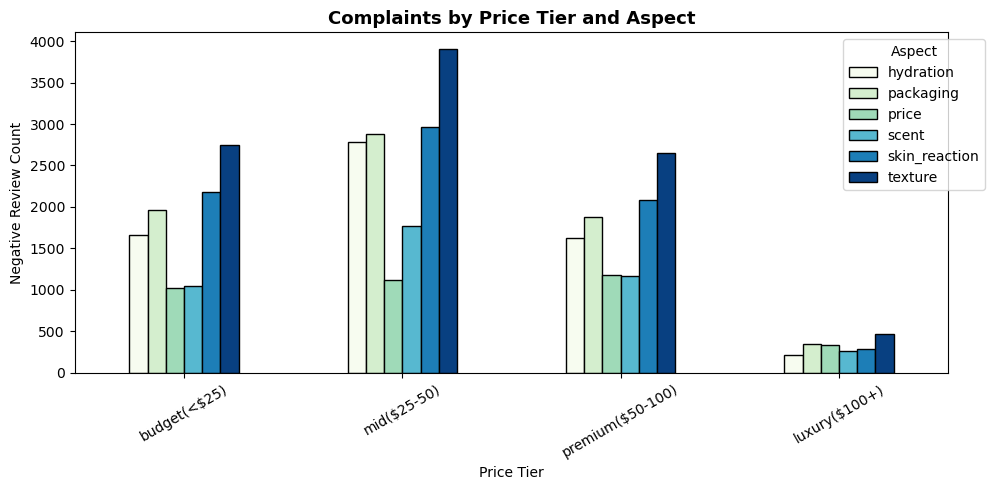

In [13]:
if 'price_tier' in df_exploded.columns:
    price_aspect = (
        df_exploded[df_exploded['sentiment_label'] == 'negative']
        .groupby(['price_tier', 'aspects'])
        .size()
        .unstack(fill_value=0)
    )
    print("Negative reviews by price tier and aspect:")
    print(price_aspect)

    price_aspect.plot(
        kind='bar',
        figsize=(10, 5),
        colormap='GnBu',
        edgecolor='black'
    )
    plt.title('Complaints by Price Tier and Aspect', fontsize=13, fontweight='bold')
    plt.xlabel('Price Tier')
    plt.ylabel('Negative Review Count')
    plt.xticks(rotation=30)
    plt.legend(title='Aspect', bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.savefig('price_tier_aspect_chart.png', dpi=150)
    plt.show()
else:
    print("price_tier column not found — skip this section.")

**Price Tier Analysis:**

Mid-tier products ($25-50) generate the highest raw complaint volume
across all aspects, consistent with their dominant 40% share of the
dataset (414,054 reviews).

However, the most strategically significant finding is in price complaints
by tier. Luxury products ($100+) generate 338 price complaints from only
54,268 reviews — a rate of 0.62%. Mid-tier generates 1,114 from 414,054 —
a rate of 0.27%. Luxury customers complain about value proportionally more
than budget customers, suggesting that premium pricing expectations
frequently go unmet.

Skin reaction complaints are distributed across ALL price tiers at
comparable rates, confirming that formulation sensitivity is not a
budget-product problem — it is an industry-wide challenge affecting
products at every price point.

## Section 10 — Final Summary Table
This table directly answers the problem statement.

In [14]:
# Total mentions per aspect
total_mentions = df_exploded.groupby('aspects').size().rename('total_mentions')

# Negative % overall
neg_pct_overall = (
    df_exploded[df_exploded['sentiment_label'] == 'negative']
    .groupby('aspects').size() / total_mentions * 100
).round(1).rename('neg_pct_all_ratings')

# Negative % within 4★+ only
total_4plus = df_4plus.groupby('aspects').size().rename('total_4plus')
neg_4plus = (
    df_4plus[df_4plus['sentiment_label'] == 'negative']
    .groupby('aspects').size()
)
neg_pct_4plus = (neg_4plus / total_4plus * 100).round(1).rename('neg_pct_4plus_ratings')

# Combine
summary = pd.concat([total_mentions, neg_pct_overall, total_4plus, neg_pct_4plus], axis=1)
summary = summary.sort_values('neg_pct_4plus_ratings', ascending=False)

print("\n=== FINAL SUMMARY TABLE ===")
print(summary.to_string())


=== FINAL SUMMARY TABLE ===
               total_mentions  neg_pct_all_ratings  total_4plus  neg_pct_4plus_ratings
aspects                                                                               
skin_reaction           74723                 10.1        60700                    5.4
packaging               61315                 11.5        45906                    4.8
price                   46752                  7.8        35700                    3.5
texture                125969                  7.8        98872                    3.5
hydration              101187                  6.2        84729                    3.4
scent                   74495                  5.7        60218                    2.3


## Findings Summary

**Core finding:** Star ratings alone do not reveal dissatisfaction at the aspect level.

| Aspect | All-rating Neg% | Hidden Neg% (4★+) | What this means |
|---|---|---|---|
| skin_reaction | ~10% | ~5.4% | Most dangerous — high rate even in praised products |
| packaging | ~11.5% | ~4.8% | Highest overall complaint rate |
| price | ~7.8% | ~3.5% | Polarising — strong opinions both ways |
| texture | ~7.8% | ~3.5% | Highest raw volume of hidden complaints |
| hydration | ~6.2% | ~3.4% | Most mentioned, mostly loved |
| scent | ~5.7% | ~2.3% | Safest aspect — overwhelmingly positive |


- `skin_reaction` and `packaging` show the highest complaint rates even inside 4★+ reviews
- Texture has the highest raw volume of hidden complaints (3,488 negative reviews in 4★+) despite a moderate complaint rate — driven by its position as the most discussed aspect with 125,969 mentions.
- `scent` and `price` are polarizing — strong opinions in both directions
  
**Skin type insight:** Texture is the #1 complaint for every skin type. Combination skin dominates all complaint categories.

**This validates the core hypothesis:** Hidden dissatisfaction exists in high-rated products, concentrated in specific aspects that star ratings cannot capture.